### Importação das bibliotecas necessárias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração para exibir os gráficos direto no notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

### Carregamento dos dados

In [2]:
# Carregando a base de treino
df_train = pd.read_csv('../train.csv')

# Carregando a base de teste
df_test = pd.read_csv('../test.csv')

print(f"Dimensões do Dataset de Treino: {df_train.shape[0]} linhas e {df_train.shape[1]} colunas.")
print(f"Dimensões do Dataset de Teste: {df_test.shape[0]} linhas e {df_test.shape[1]} colunas.")

Dimensões do Dataset de Treino: 32769 linhas e 10 colunas.
Dimensões do Dataset de Teste: 58921 linhas e 10 colunas.


### Visualizando as primeiras linhas

In [3]:
# Olhar a estrutura dos dados
df_train.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


### Primeira verificação de tipos e estatísticas dos dados

In [6]:
print("--- Informações do Dataset de Treino ---")
df_train.info()

print("\n--- Descrição do Dataset de Treino ---")
display(df_train.describe())

--- Informações do Dataset de Treino ---
<class 'pandas.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB

--- Descrição do Dataset de Treino ---


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
count,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000,32769.000000
mean,0.942110,42923.916171,25988.957979,116952.627788,118301.823156,118912.779914,125916.152644,170178.369648,183703.408893,119789.430132
std,0.233539,34173.892702,35928.031650,10875.563591,4551.588572,18961.322917,31036.465825,69509.462130,100488.407413,5784.275516
min,0.000000,0.000000,25.000000,4292.000000,23779.000000,4674.000000,117879.000000,4673.000000,3130.000000,117880.000000
25%,1.000000,20299.000000,4566.000000,117961.000000,118102.000000,118395.000000,118274.000000,117906.000000,118363.000000,118232.000000
50%,1.000000,35376.000000,13545.000000,117961.000000,118300.000000,118921.000000,118568.000000,128696.000000,119006.000000,118570.000000
75%,1.000000,74189.000000,42034.000000,117961.000000,118386.000000,120535.000000,120006.000000,235280.000000,290919.000000,119348.000000
max,1.000000,312153.000000,311696.000000,311178.000000,286791.000000,286792.000000,311867.000000,311867.000000,308574.000000,270691.000000


### Verificação de valores únicos, dados faltantes e duplicatas

In [25]:
print("--- Quantidade de Valores únicos por Coluna ---")
for col in df_train.columns:
  unique_values = df_train[col].nunique()
  print(f'{col}: {unique_values} valores únicos')

print("\n--- Quantidade de Valores Nulos por Coluna ---")
print(df_train.isnull().sum())

print("\n--- Quantidade de Valores Duplicados ---")
print(df_train.duplicated().sum())

--- Quantidade de Valores únicos por Coluna ---
ACTION: 2 valores únicos
RESOURCE: 7518 valores únicos
MGR_ID: 4243 valores únicos
ROLE_ROLLUP_1: 128 valores únicos
ROLE_ROLLUP_2: 177 valores únicos
ROLE_DEPTNAME: 449 valores únicos
ROLE_TITLE: 343 valores únicos
ROLE_FAMILY_DESC: 2358 valores únicos
ROLE_FAMILY: 67 valores únicos
ROLE_CODE: 343 valores únicos

--- Quantidade de Valores Nulos por Coluna ---
ACTION              0
RESOURCE            0
MGR_ID              0
ROLE_ROLLUP_1       0
ROLE_ROLLUP_2       0
ROLE_DEPTNAME       0
ROLE_TITLE          0
ROLE_FAMILY_DESC    0
ROLE_FAMILY         0
ROLE_CODE           0
dtype: int64

--- Quantidade de Valores Duplicados ---
0


### Análise do Desbalanceamento da Target

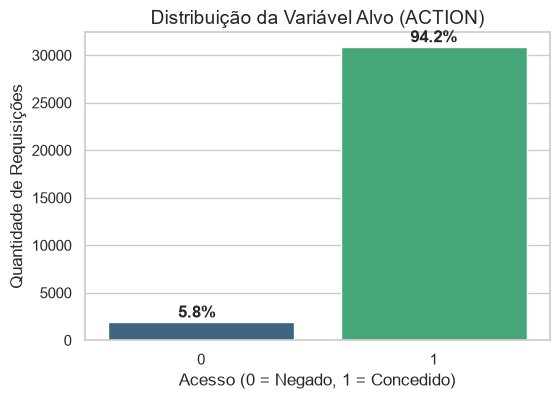


Valores absolutos:
ACTION
1    30872
0     1897
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='ACTION', data=df_train, hue='ACTION', palette='viridis', legend=False)

# Adicionando a porcentagem em cima das barras
total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 500
    ax.annotate(percentage, (x_coord, y_coord), fontsize=12, fontweight='bold')

plt.title('Distribuição da Variável Alvo (ACTION)', fontsize=14)
plt.xlabel('Acesso (0 = Negado, 1 = Concedido)', fontsize=12)
plt.ylabel('Quantidade de Requisições', fontsize=12)
plt.show()

print("\nValores absolutos:")
print(df_train['ACTION'].value_counts())